In [1]:
import xarray as xr 
from anemoi.datasets import open_dataset
import matplotlib.pyplot as plt
import matplotlib.tri as tri
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

In [3]:
!anemoi-datasets inspect CERRA_BOZ.zarr

📦 Path          : CERRA_BOZ.zarr
🔢 Format version: 0.30.0

📅 Start      : 2023-01-01 00:00
📅 End        : 2024-10-31 21:00
⏰ Frequency  : 3h
🚫 Missing    : 0
🌎 Resolution : None
🌎 Field shape: [22, 27]

📐 Shape      : 5,360 × 28 × 1 × 594 (340.1 MiB)
💽 Size       : 204 MiB (204 MiB)
📁 Files      : 5,404

   Index │ Variable   │         Min │      Max │      Mean │    Stdev
   ──────┼────────────┼─────────────┼──────────┼───────────┼─────────
       0 │ cos_doy    │   -0.999963 │        1 │ 0.0240754 │ 0.698985
       1 │ coswdir10  │          -1 │        1 │ -0.173358 │ 0.685794
       2 │ coswdir100 │          -1 │        1 │ -0.170284 │ 0.674041
       3 │ coswdir150 │          -1 │        1 │ -0.164793 │ 0.667598
       4 │ coswdir200 │          -1 │        1 │ -0.158095 │ 0.661549
       5 │ coswdir50  │          -1 │        1 │ -0.173565 │ 0.680446
       6 │ mcc        │           0 │      100 │   35.0833 │  38.2519
       7 │ msl        │     95769.4 │   104561 │    101365 │  11

In [28]:
!zarrdump CERRA5.zarr

/mnt/data/weatherloss/WindPower/WindPower/lib/python3.12/site-packages/zarrdump/core.py:84: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  result = xr.open_zarr(url, storage_options=storage_option)
<xarray.Dataset> Size: 166MB
Dimensions:     (variable: 13, time: 5360, ensemble: 1, cell: 594)
Dimensions without coordinates: variable, time, ensemble, cell
Data variables:
    count       (variable) float64 104B dask.array<chunksize=(13,), meta=np.ndarray>
    data        (time, variable, ensemble, cell) float32 166MB 

In [32]:
ds = xr.open_zarr("CERRA5.zarr", consolidated=False)

In [43]:
def plot_var_anemoi(ds, var="t2m", when="2024-01-15T12:00",
                    extent=(1.9,4.1,50.9,52.1), to_celsius=True, cmap="coolwarm"):

    var_names = list(ds.attrs["variables"])        # ['cos_doy','coswdir10',...,'ws100']
    v_idx = var_names.index(var)

    times = np.asarray(ds["dates"].values)         # (time,)
    target = np.datetime64(when)
    t_idx = int(np.argmin(np.abs(times - target)))
    t_label = str(times[t_idx])

    # --- read lon/lat 1-D and reshape to (ny,nx)
    ny, nx = ds.attrs["field_shape"]               # [22, 27]
    lon2d = np.asarray(ds["longitudes"].values).reshape(ny, nx)
    lat2d = np.asarray(ds["latitudes"].values).reshape(ny, nx)
    lon2d = ((lon2d + 180) % 360) - 180            # safe wrap

    # --- extract the 1-D field and reshape
    # data dims: (time, variable, ensemble, cell)
    vals1d = ds["data"].isel(time=t_idx, variable=v_idx, ensemble=0).values  # (594,)
    vals2d = vals1d.reshape(ny, nx)

    # --- unit fix for temperature
    units = ""
    if var == "t2m" and to_celsius:
        vals2d = vals2d - 273.15
        units = "°C"

    # --- plot
    proj = ccrs.PlateCarree()
    fig, ax = plt.subplots(figsize=(9,7), subplot_kw=dict(projection=proj))
    ax.set_extent(extent, crs=proj)
    ax.coastlines("50m", linewidth=1)
    ax.add_feature(cfeature.BORDERS, linewidth=0.8)

    mesh = ax.pcolormesh(lon2d, lat2d, vals2d, shading="nearest",
                         cmap=cmap, transform=proj)
    gl = ax.gridlines(draw_labels=True, linewidth=0.4, alpha=0.5)
    gl.top_labels = False; gl.right_labels = False

    plt.colorbar(mesh, ax=ax, orientation="horizontal", pad=0.05, label=units)
    plt.title(f"{var} @ {t_label}")
    plt.tight_layout()
    plt.show()


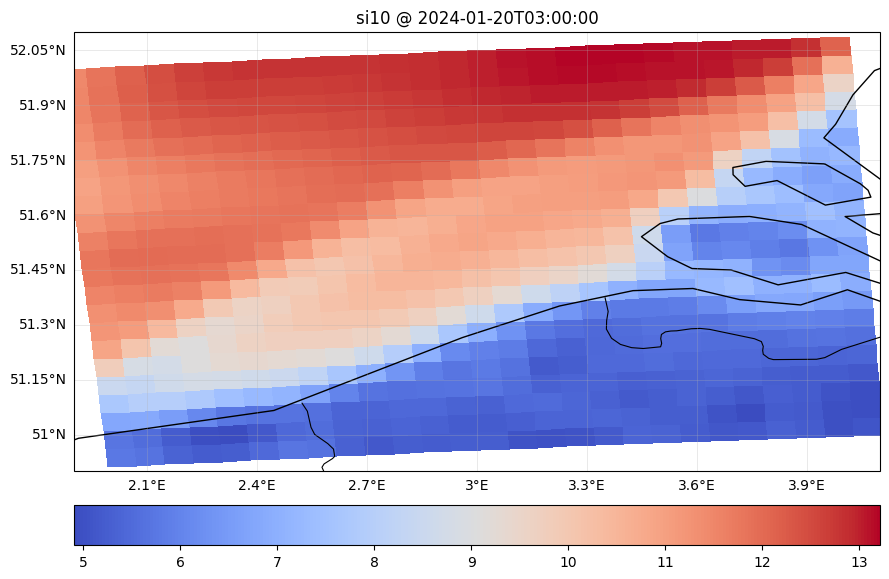

In [48]:
plot_var_anemoi(ds, var="si10", when="2024-01-20T03:00")